In [131]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier,plot_tree

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import gradio
sns.set_style("whitegrid")

In [132]:
df = pd.read_csv('student_pass_fail.csv')

In [133]:
df.head()

,study_hours,attendance_percentage,previous_exam_score,sleep_hours,passed
0,3.7,43.1,41.8,5.0,0
1,9.5,71.9,49.5,4.1,1
2,7.3,72.4,42.4,4.9,0
3,6.0,78.2,36.2,6.9,1
4,1.6,83.6,38.4,6.1,0


In [134]:
df.shape


(300, 5)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            300 non-null    float64
 1   attendance_percentage  300 non-null    float64
 2   previous_exam_score    300 non-null    float64
 3   sleep_hours            300 non-null    float64
 4   passed                 300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [136]:
df.isnull().sum()

study_hours              0
attendance_percentage    0
previous_exam_score      0
sleep_hours              0
passed                   0
dtype: int64

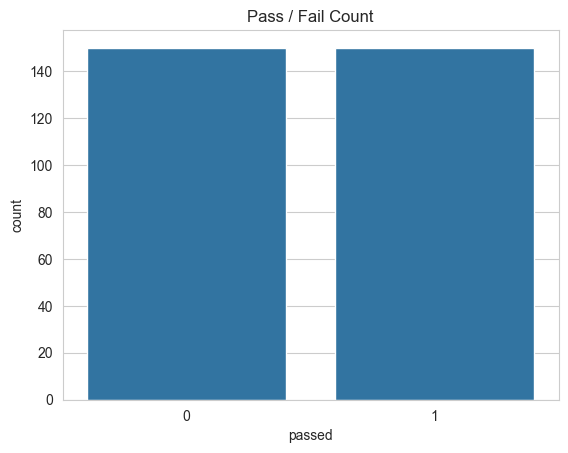

In [137]:
sns.countplot(x='passed', data=df)

plt.title("Pass / Fail Count")
plt.show()

In [138]:
X = df.drop('passed', axis=1)

y = df['passed']

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [140]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [141]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [142]:
from sklearn import tree

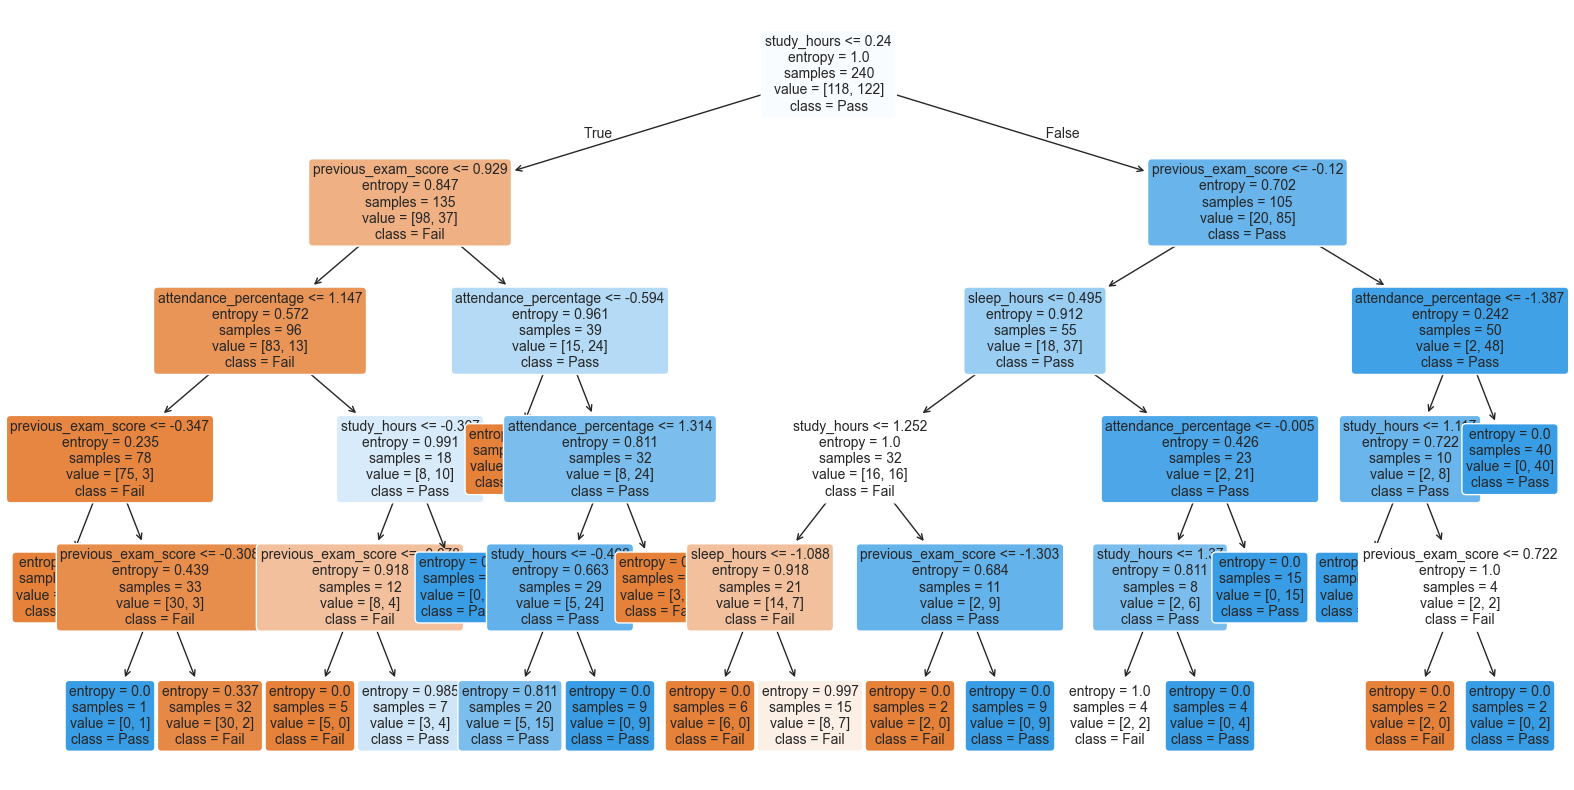

In [143]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [144]:
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy =", acc_dt)

Decision Tree Accuracy = 0.85


In [145]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



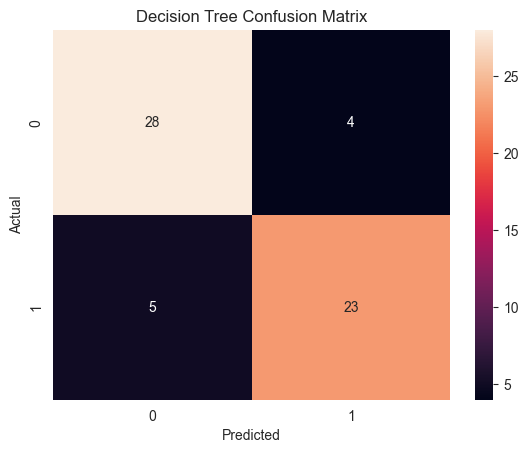

In [146]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()